Fidel Garcia Villa Jr. 
DSC-580: Milestone 3

In [ ]:
#Modules needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

: 

In [1]:
import tensorflow as tf
print(tf.__version__)

: 

In [20]:
# Load datatset
dataset = pd.read_csv('./src/the_global_k_anon_dataset.csv', sep=';', low_memory=False)
dataset = dataset.drop(dataset.columns[0], axis=1)

#Filter only for US data
top_exploitation_countries = ['US', 'RU', 'PH', 'ID', 'KH']
dataset = dataset[dataset['CountryOfExploitation'].isin(top_exploitation_countries)]

# Understand the structure of the dataset
print(dataset.shape)
print(dataset.columns)
print(dataset.dtypes)

# Missing Values
dataset.isna().sum().sort_values(ascending=False)
(dataset.isna().mean() * 100).sort_values(ascending=False)

# Categorical Distribution
print(dataset['gender'].value_counts())
print(dataset['ageBroad'].value_counts())
print(dataset['citizenship'].value_counts())
print(dataset['isForcedLabour'].value_counts())
print(dataset['isSexualExploit'].value_counts())
print(dataset['CountryOfExploitation'].value_counts().head(10))

# EDA Numerical Data
dataset.describe()

(62064, 63)
Index(['yearOfRegistration', 'Datasource', 'gender', 'ageBroad',
       'majorityStatus', 'majorityStatusAtExploit', 'majorityEntry',
       'citizenship', 'meansOfControlDebtBondage',
       'meansOfControlTakesEarnings', 'meansOfControlRestrictsFinancialAccess',
       'meansOfControlThreats', 'meansOfControlPsychologicalAbuse',
       'meansOfControlPhysicalAbuse', 'meansOfControlSexualAbuse',
       'meansOfControlFalsePromises', 'meansOfControlPsychoactiveSubstances',
       'meansOfControlRestrictsMovement', 'meansOfControlRestrictsMedicalCare',
       'meansOfControlExcessiveWorkingHours', 'meansOfControlUsesChildren',
       'meansOfControlThreatOfLawEnforcement',
       'meansOfControlWithholdsNecessities',
       'meansOfControlWithholdsDocuments', 'meansOfControlOther',
       'meansOfControlNotSpecified', 'meansOfControlConcatenated',
       'isForcedLabour', 'isSexualExploit', 'isOtherExploit', 'isSexAndLabour',
       'isForcedMarriage', 'isForcedMilitary', 'i

,yearOfRegistration,meansOfControlDebtBondage,meansOfControlTakesEarnings,meansOfControlRestrictsFinancialAccess,meansOfControlThreats,meansOfControlPsychologicalAbuse,meansOfControlPhysicalAbuse,meansOfControlSexualAbuse,meansOfControlFalsePromises,meansOfControlPsychoactiveSubstances,...,typeOfSexProstitution,typeOfSexPornography,typeOfSexRemoteInteractiveServices,typeOfSexPrivateSexualServices,isAbduction,recruiterRelationIntimatePartner,recruiterRelationFriend,recruiterRelationFamily,recruiterRelationOther,recruiterRelationUnknown
count,62064.000000,5914.000000,9022.000000,2489.000000,13062.000000,12298.000000,9490.000000,6658.000000,5507.000000,8799.000000,...,31095.000000,28672.000000,28672.000000,27700.000000,19095.000000,23469.000000,23469.000000,23469.000000,23469.000000,62064.000000
mean,2017.226959,0.596212,0.870206,0.191241,0.882024,0.898845,0.771233,0.559628,0.793899,0.669622,...,0.414215,0.061244,0.004116,0.017581,0.019063,0.153479,0.094380,0.117346,0.342494,0.741170
std,2.180535,0.490697,0.336095,0.393358,0.322592,0.301546,0.420061,0.496469,0.404541,0.470376,...,0.492594,0.239782,0.064021,0.131426,0.136749,0.360456,0.292363,0.321839,0.474554,0.437995
min,2004.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2018.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,2019.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,2020.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: >

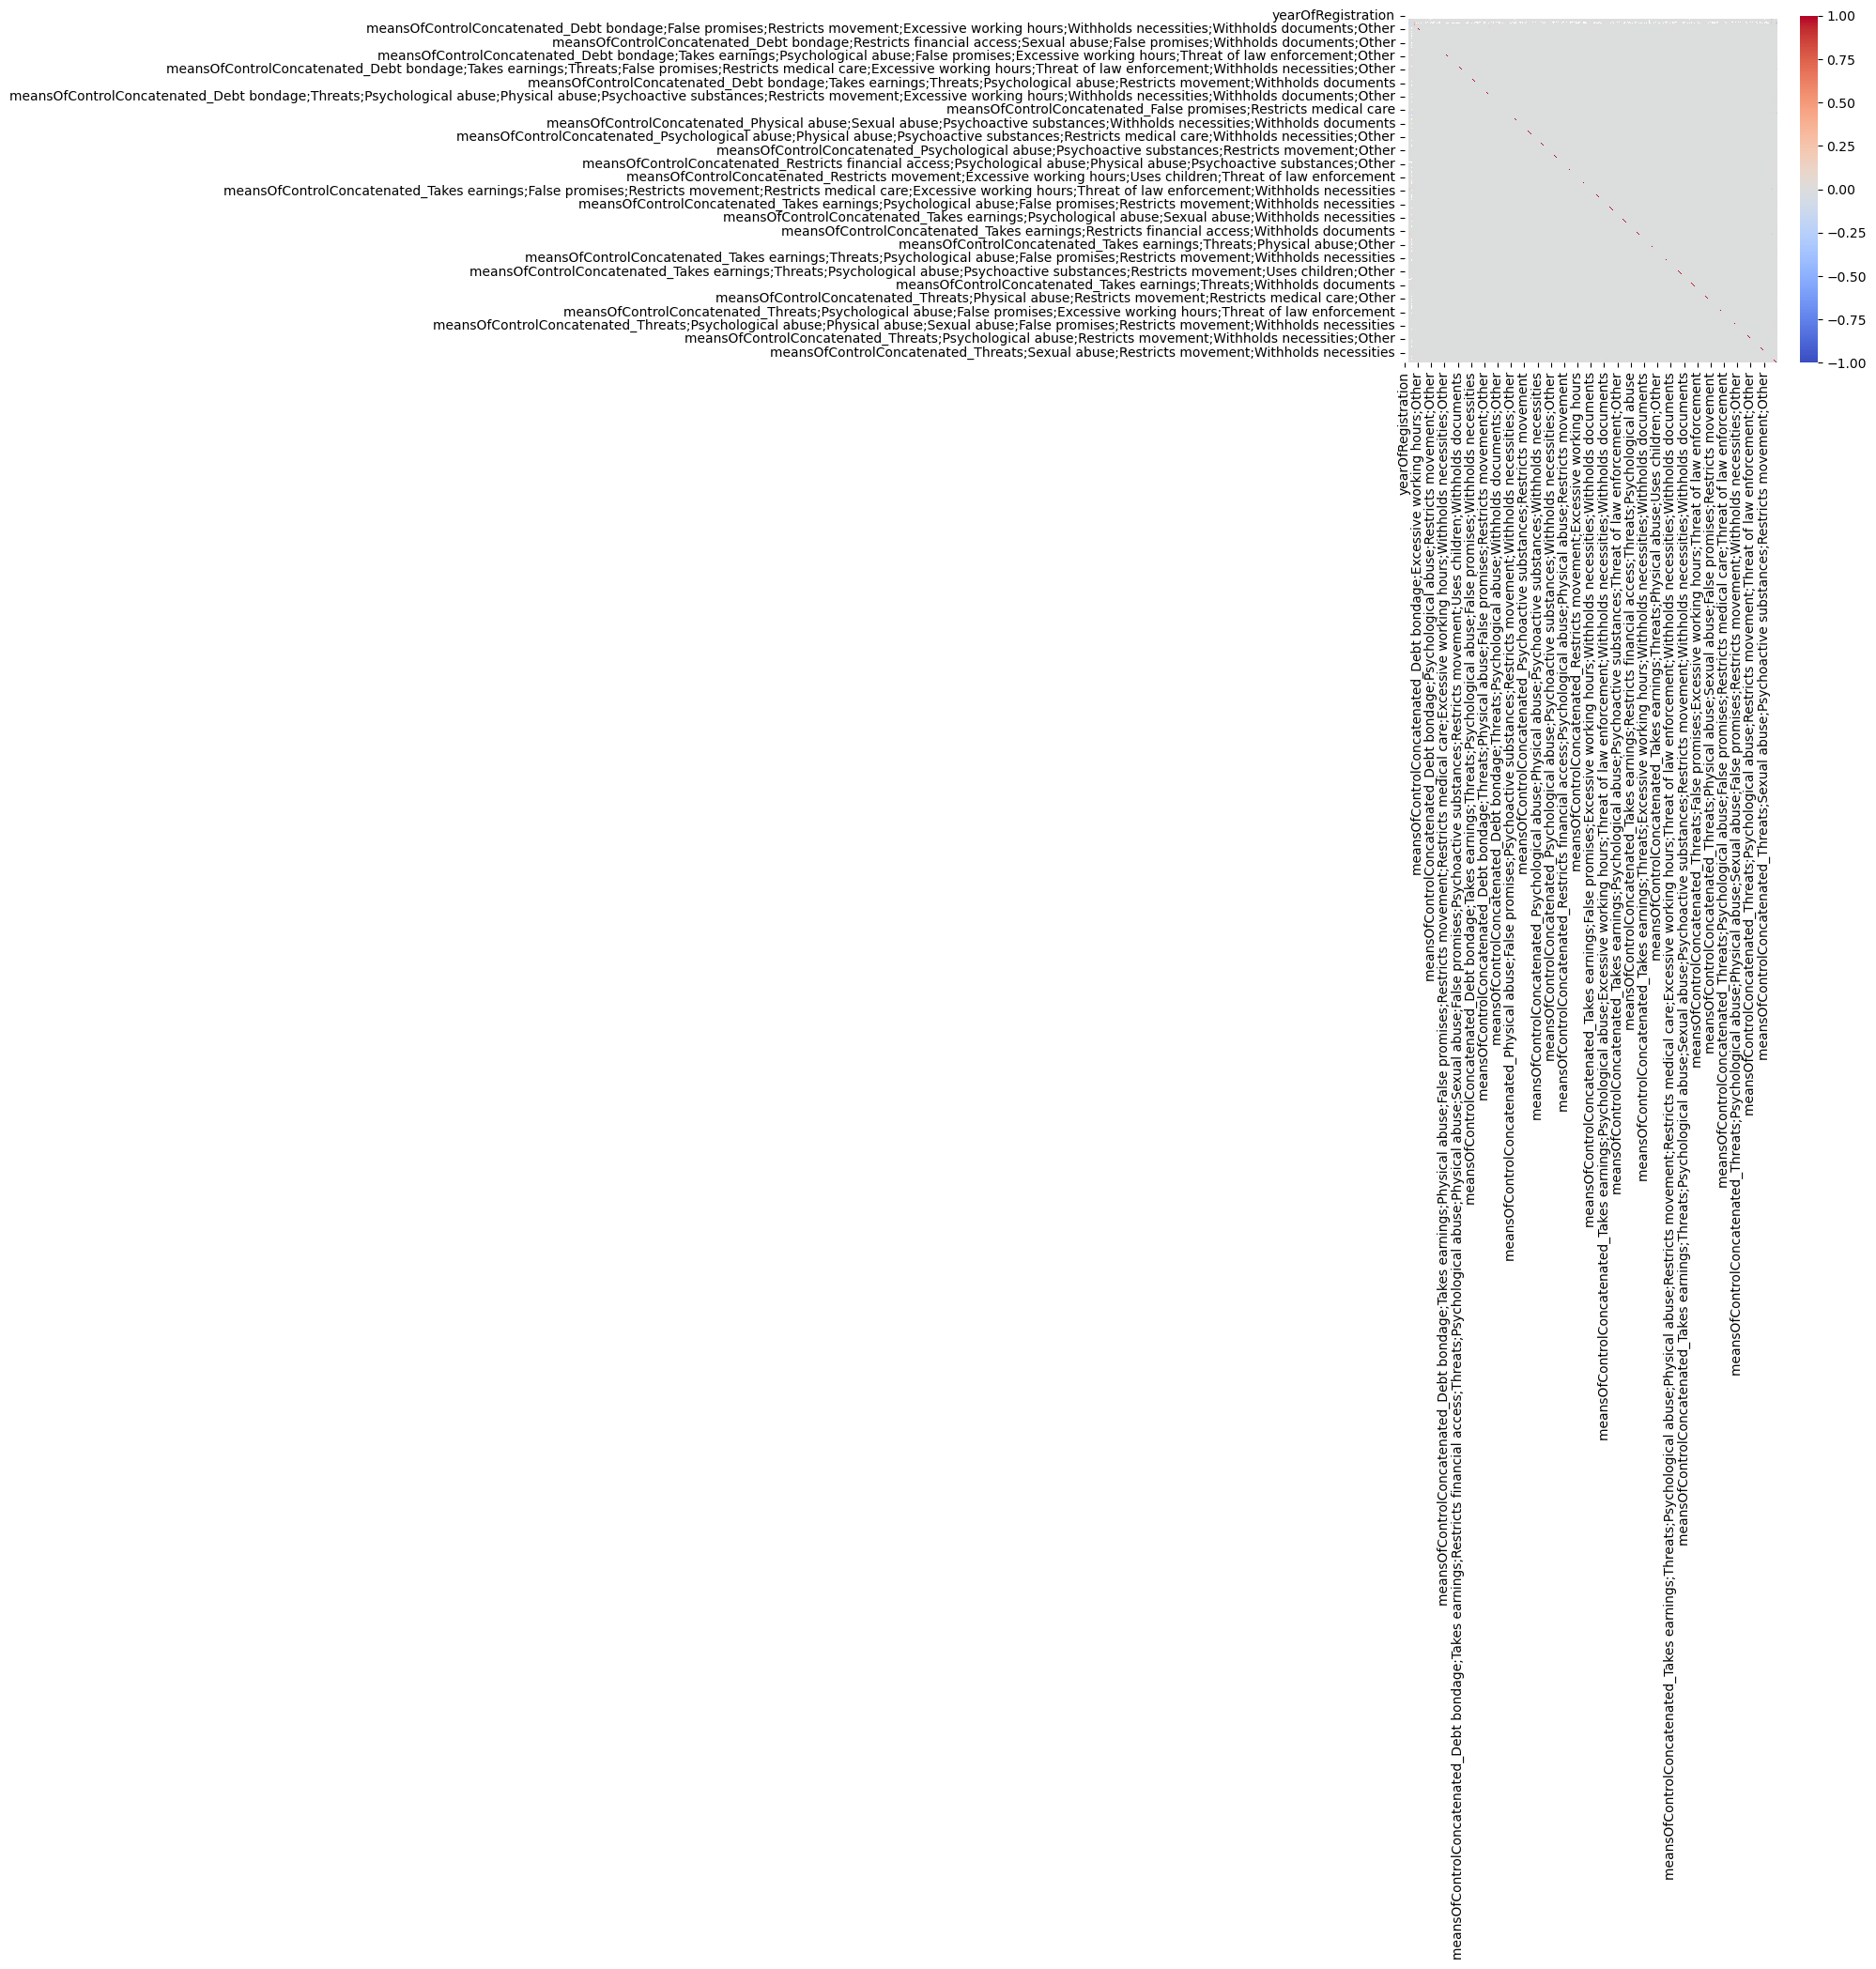

In [ ]:
# Visualizations (Heatmap)
# encoded = pd.get_dummies(dataset, drop_first=True)
# sns.heatmap(encoded.corr(), cmap='coolwarm')

In [ ]:
print(dataset.columns)

# Split Data into Features and Target
X = encoded.drop('CountryOfExploitation', axis=1)
y = encoded['CountryOfExploitation']

# Convert target to categorical
y = pd.get_dummies(y)
num_countries = y.shape[1]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42)

Index(['yearOfRegistration', 'Datasource', 'gender', 'ageBroad',
       'majorityStatus', 'majorityStatusAtExploit', 'majorityEntry',
       'citizenship', 'meansOfControlDebtBondage',
       'meansOfControlTakesEarnings', 'meansOfControlRestrictsFinancialAccess',
       'meansOfControlThreats', 'meansOfControlPsychologicalAbuse',
       'meansOfControlPhysicalAbuse', 'meansOfControlSexualAbuse',
       'meansOfControlFalsePromises', 'meansOfControlPsychoactiveSubstances',
       'meansOfControlRestrictsMovement', 'meansOfControlRestrictsMedicalCare',
       'meansOfControlExcessiveWorkingHours', 'meansOfControlUsesChildren',
       'meansOfControlThreatOfLawEnforcement',
       'meansOfControlWithholdsNecessities',
       'meansOfControlWithholdsDocuments', 'meansOfControlOther',
       'meansOfControlNotSpecified', 'meansOfControlConcatenated',
       'isForcedLabour', 'isSexualExploit', 'isOtherExploit', 'isSexAndLabour',
       'isForcedMarriage', 'isForcedMilitary', 'isOrganRemova

In [ ]:
# Build the Model
